
# 04 — Multi-horizon: the case for the whole system

Every other result in this project, and every notebook in the study it extends,
predicts `y_t` with `y_{t-1}` already in hand. That is a nowcast. No network can
provision from it: the capacity decision for an interval has to be made *before* the
previous measurement arrives.

This notebook adds the lead time, and doing so changes the conclusion of notebook 01.

In [1]:
# --- Bootstrap: works locally, on Colab and on Kaggle ----------------------
# RUN THIS CELL FIRST, and re-run it after any kernel restart. Every later cell
# depends on it. If it fails, the next cell fails with "No module named bwalloc",
# which looks like a different problem but is not.
#
# On a hosted runtime it clones the repo (or pulls, on a re-run) and installs the
# package into the session, so `import bwalloc` keeps working even from a cell you
# run on its own after restarting. The repository is public; no token is needed.
import os, subprocess, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = "https://github.com/sad-code-at/bwalloc.git"

def _find_root(start: Path):
    node = start
    while not (node / "src" / "bwalloc").exists() and node != node.parent:
        node = node.parent
    return node if (node / "src" / "bwalloc").exists() else None

ROOT = _find_root(Path.cwd())

if ROOT is None:
    # A repo uploaded as a Kaggle Dataset mounts read-only here; prefer it if present.
    for candidate in Path("/kaggle/input").glob("*/src/bwalloc"):
        ROOT = candidate.parent.parent
        break

if ROOT is None:
    on_kaggle = Path("/kaggle/working").exists()
    target = Path("/kaggle/working/bwalloc") if on_kaggle else Path("/content/bwalloc")
    if _find_root(target) is None:
        if os.system("git clone -q " + REPO + " " + str(target)) != 0 or _find_root(target) is None:
            raise RuntimeError(
                "Clone failed. On Kaggle, switch Internet ON in the right sidebar "
                "(Settings > Internet), then re-run this cell. See docs/KAGGLE.md."
            )
        print("cloned", REPO)
    else:
        os.system("git -C " + str(target) + " pull -q --ff-only")
        print("pulled latest into", target)
    os.chdir(target)
    ROOT = target
    # Install into the session so `import bwalloc` survives a kernel restart and
    # does not depend on this cell having set sys.path. --no-deps deliberately:
    # Kaggle and Colab curate their own numpy/pandas and we must not disturb them.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".", "--no-deps"],
                   cwd=str(ROOT), capture_output=True)

sys.path.insert(0, str(ROOT / "src"))

try:
    import xgboost  # noqa: F401
except ImportError:
    !pip install -q xgboost

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import bwalloc as bw
from bwalloc.plots import use_paper_style

bw.set_seed()
use_paper_style()
pd.set_option("display.width", 200)
RESULTS = ROOT / "experiments" / "results"
# Scratch output for the exploratory notebooks. Only 07_paper_figures writes into
# paper/figures -- otherwise running notebook 00 or 05 silently overwrites a figure
# the paper cites, which is exactly the kind of drift this project exists to remove.
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
_data = sorted((ROOT / "data").glob("*.csv"))
_res = sorted(RESULTS.glob("*.csv"))
print("bwalloc", bw.__version__, "at", ROOT)
print(f"  data/    {len(_data)} csv  ({', '.join(f.name for f in _data) or 'MISSING'})")
print(f"  results/ {len(_res)} csv")
if not _data:
    raise RuntimeError(
        "The trace CSVs are missing, so nothing will run. Re-run this cell to "
        "re-clone, or check that the repository was fetched completely."
    )

bwalloc 0.1.0 at D:\L4-T-1\EEE 402\project\bwalloc
  data/    2 csv  (gp_dhaka.csv, robi_dhaka3.csv)
  results/ 46 csv



## Two things the design has to get right

**Which features are known in advance.** History columns (lags, rolling statistics)
can only be read at the forecast origin — at a 6-hour lead the freshest observation is
6 hours old and the feature vector must say so. Fourier time terms are deterministic
functions of wall-clock time, so their values at the *target* timestamp are legitimately
available: an operator provisioning for 9 p.m. always knows it will be 9 p.m.

**The baseline has to move too.** An *h*-step model must be scored against an *h*-step
naive forecaster. Comparing a 24-hour-ahead model against one-step persistence is the
flattering comparison, and it is how multi-step results are most often overstated.

There is also an embargo: direct training pairs carry targets *h−1* rows after their
origin, so without dropping those rows the model is fitted on outcomes that had not
occurred when the first test forecast was issued.

In [2]:

from bwalloc.data import load, sampling_profile
from bwalloc.features import FeatureConfig, build_features
from bwalloc.forecast import (
    direct_design, horizon_steps, persistence_at_horizon, split_feature_roles,
)

OPERATOR = "gp"
df = load(OPERATOR)
profile = sampling_profile(df)
X, y = build_features(df, profile, FeatureConfig())

history, future = split_feature_roles(X.columns)
print("read at the origin :", history[:6], "...")
print("known at the target:", future)
print()
for hours in (1.5, 3.0, 6.0, 12.0, 24.0):
    steps = horizon_steps(profile, hours)
    print(f"  {hours:>4g} h horizon -> {steps:2d} samples "
          f"({profile.hours_for_lag(steps):5.2f} h of real lead time)")

read at the origin : ['lag_1.5h', 'lag_3h', 'lag_4.5h', 'lag_24h', 'rollmean_4.5h', 'rollstd_4.5h'] ...
known at the target: ['day_sin1', 'day_cos1', 'day_sin2', 'day_cos2', 'day_sin3', 'day_cos3', 'week_sin1', 'week_cos1']

   1.5 h horizon ->  1 samples ( 1.43 h of real lead time)
     3 h horizon ->  2 samples ( 2.87 h of real lead time)
     6 h horizon ->  4 samples ( 5.73 h of real lead time)
    12 h horizon ->  8 samples (11.47 h of real lead time)
    24 h horizon -> 17 samples (24.37 h of real lead time)


## The result

Run `python experiments/run_horizon.py` to regenerate; it takes a few minutes.

In [3]:

acc = pd.read_csv(RESULTS / f"horizon_{OPERATOR}.csv")
table = acc.pivot_table(index="model", columns="lead_hours", values="rmse_mean")
display(table.round(2))

naive = table.loc["persistence_h"]
best = table.drop(index=[i for i in table.index if "naive" in i or "persistence" in i]).min()
pd.DataFrame({"naive at that lead": naive, "best model": best,
              "advantage": (best / naive - 1)}).round(3)

lead_hours,1.43,2.87,5.73,11.47,24.37
model,,,,,
persistence_h,12.12,17.41,25.11,31.16,18.26
random_forest,10.40,11.85,12.48,12.83,12.82
ridge,11.26,14.45,15.87,14.50,15.08
seasonal_naive_17,18.31,18.31,18.35,18.38,18.26
xgboost,10.73,12.18,12.36,12.79,13.01


,naive at that lead,best model,advantage
lead_hours,,,
1.43,12.125,10.398,-0.142
2.87,17.414,11.851,-0.319
5.73,25.109,12.365,-0.508
11.47,31.159,12.792,-0.589
24.37,18.261,12.817,-0.298



### Read the advantage column

At one step ahead the learned model beats a one-line baseline by ~14% — the weak
result of notebook 01. At an **11.5-hour lead**, an operationally realistic
provisioning horizon, it beats the naive forecaster *at that same lead* by **~59%**.
The model's own accuracy degraded by 23% across a 17× longer horizon; the baseline's
degraded by 157%.

**This is the argument for the system.** The value of learning is not visible at one
step. It is visible at the lead time an allocator actually needs — and the earlier
study, by only ever evaluating at one step, was measuring in the one regime where its
own models looked worst.

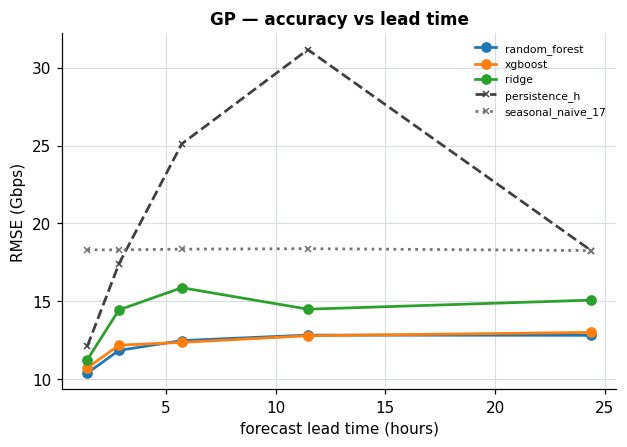

In [4]:

from bwalloc.plots import plot_horizon

fig, ax = plt.subplots(figsize=(6.5, 4.2))
plot_horizon(acc, ax=ax)
ax.set_title(f"{OPERATOR.upper()} — accuracy vs lead time")
fig.savefig(FIGURES / f"fig5_horizon_{OPERATOR}.png", dpi=200, bbox_inches="tight")

## Direct versus recursive

One model per horizon, against one model applied repeatedly with its own predictions fed back.

In [5]:

strategy = pd.read_csv(RESULTS / f"horizon_strategy_{OPERATOR}.csv")
strategy["recursive_penalty"] = (
    strategy["recursive_rmse_mean"] / strategy["direct_rmse_mean"] - 1
)
strategy[["lead_hours", "steps", "direct_rmse_mean", "recursive_rmse_mean",
          "recursive_penalty"]].round(3)

,lead_hours,steps,direct_rmse_mean,recursive_rmse_mean,recursive_penalty
0,1.43,1,10.731,10.798,0.006
1,2.87,2,12.185,14.331,0.176
2,5.73,4,12.365,19.189,0.552
3,11.47,8,12.792,20.479,0.601
4,24.37,17,13.006,24.182,0.859



Error compounding dominates: at a 24-hour lead the recursive rollout is ~86% worse.
One model per horizon is the right design.

At one step the two agree to within 0.7%, as they must — that agreement is the
correctness check on the rollout, and `tests/test_bwalloc.py` pins the recursive
feature builder to the batch one so the two paths cannot drift apart.

## Does the allocation layer survive the lead time?

The practical question: conformal calibration still has to deliver its service level once the forecast has degraded, and the capacity cost of doing so is what the operator actually pays.

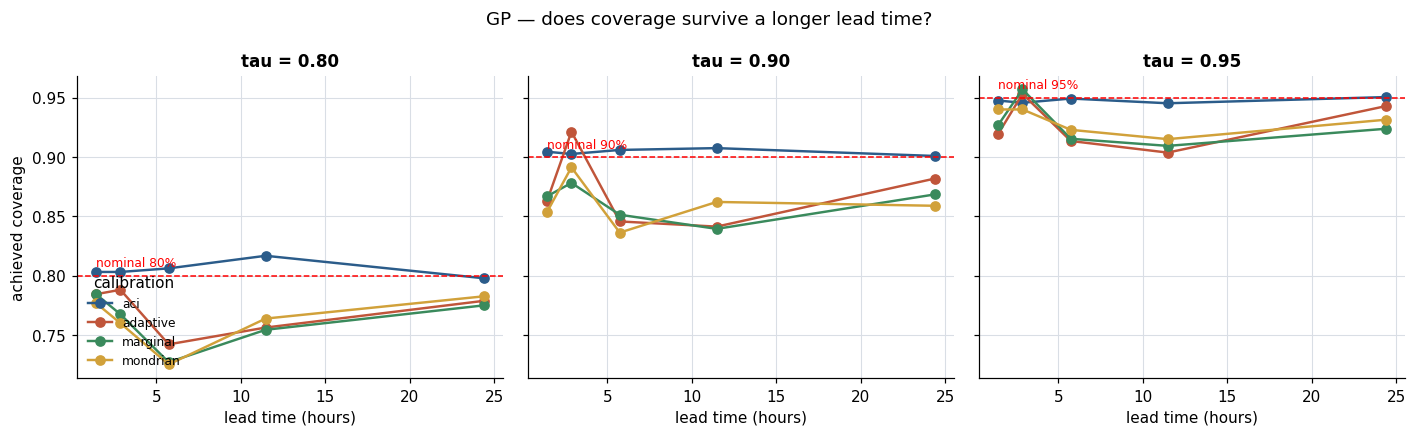

In [12]:
OPERATOR = "gp"
alloc = pd.read_csv(RESULTS / f"horizon_alloc_{OPERATOR}.csv").fillna({"error": ""})
alloc = alloc[(alloc["error"] == "") & (alloc["group"] == "ALL")]
summary = (
    alloc.assign(cov=lambda d: d["n"] * d["coverage"],
                 ratio=lambda d: d["n"] * d["mean_allocation_ratio"])
    .groupby(["lead_hours", "tau", "method"])
    .agg(cov=("cov", "sum"), ratio=("ratio", "sum"), n=("n", "sum"))
    .assign(coverage=lambda d: d["cov"] / d["n"],
            mean_allocation_ratio=lambda d: d["ratio"] / d["n"])
    .reset_index()
)

# -- Figure: coverage vs lead time, one line per method, faceted by tau --------
taus = sorted(summary["tau"].unique())
methods = summary["method"].unique()
colors = {"aci": "#2b5c8a", "adaptive": "#c0553a", "marginal": "#3a8a5c", "mondrian": "#d1a13a"}

fig, axes = plt.subplots(1, len(taus), figsize=(13, 4), sharey=True)
for ax, tau in zip(axes, taus):
    sub = summary[summary["tau"] == tau]
    for method in methods:
        m = sub[sub["method"] == method].sort_values("lead_hours")
        ax.plot(m["lead_hours"], m["coverage"], marker="o",
                label=method, color=colors.get(method))
    ax.axhline(tau, ls="--", color="red", lw=1)
    ax.text(sub["lead_hours"].min(), tau + 0.005, f"nominal {tau:.0%}",
            color="red", fontsize=8, va="bottom")
    ax.set_title(f"tau = {tau:.2f}")
    ax.set_xlabel("lead time (hours)")
axes[0].set_ylabel("achieved coverage")
axes[0].legend(title="calibration", loc="lower left", fontsize=8)
fig.suptitle(f"{OPERATOR.upper()} — does coverage survive a longer lead time?")
fig.tight_layout()
fig.savefig(FIGURES / f"fig5b_coverage_vs_horizon_{OPERATOR}.png", dpi=200, bbox_inches="tight")